In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("final_merged.csv")
display(df.head())

Saving final_merged.csv to final_merged (1).csv


,Year,Month,State,Value,Temperature,GDP
0,2019,1,Andaman and Nicobar,118.87,17.9152,2.689205e+12
1,2019,1,Andhra Pradesh,10973.98,17.9152,2.689205e+12
2,2019,1,Arunachal Pradesh,184.86,17.9152,2.689205e+12
3,2019,1,Assam,1295.02,17.9152,2.689205e+12
4,2019,1,Bihar,6382.87,17.9152,2.689205e+12


In [ ]:
# create date column
df["Date"] = pd.to_datetime(df[["Year","Month"]].assign(DAY=1))

# aggregate all states
national = df.groupby("Date").agg({
    "Value":"sum",
    "Temperature":"mean",
    "GDP":"mean"
}).reset_index()

national.rename(columns={"Value":"Demand"}, inplace=True)

national = national.sort_values("Date")

print(national.head())

        Date     Demand  Temperature           GDP
0 2019-01-01  444573.73      17.9152  2.689205e+12
1 2019-02-01  406754.66      20.5199  2.689205e+12
2 2019-03-01  471944.93      24.3576  2.689205e+12
3 2019-04-01  479121.88      28.9504  2.689205e+12
4 2019-05-01  520028.81      30.6512  2.689205e+12


In [ ]:
# time features
national["month"] = national["Date"].dt.month
national["year"] = national["Date"].dt.year

# lag features
for lag in [1,2,3,6,12]:
    national[f"lag_{lag}"] = national["Demand"].shift(lag)

# rolling averages
national["rolling_mean_3"] = national["Demand"].rolling(3).mean()
national["rolling_mean_6"] = national["Demand"].rolling(6).mean()

national = national.dropna()

In [ ]:
train = national[national["Date"] < "2022-01-01"]
test = national[national["Date"] >= "2022-01-01"]

X_train = train.drop(["Demand","Date"],axis=1)
y_train = train["Demand"]

X_test = test.drop(["Demand","Date"],axis=1)
y_test = test["Demand"]

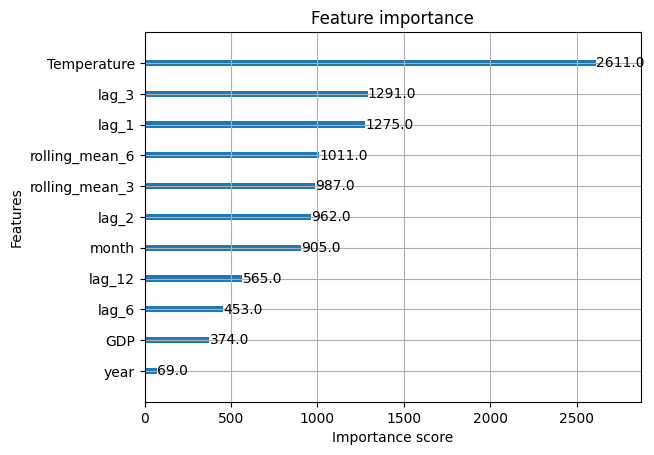

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb_model)
plt.show()

MODEL 1 - SARIMA

In [ ]:
try:
    import pmdarima as pm
except ImportError:
    %pip install pmdarima
    import pmdarima as pm

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train["Demand"])
print(result)

(np.float64(1.0787477271913786), np.float64(0.995031098833229), 9, 14, {'1%': np.float64(-4.01203360058309), '5%': np.float64(-3.1041838775510207), '10%': np.float64(-2.6909873469387753)}, np.float64(331.2708410403183))


In [ ]:
import statsmodels.api as sm

sarima_model = sm.tsa.statespace.SARIMAX(
    train["Demand"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

forecast_sarima = sarima_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results wi

MODEL 2 - XGBOOST

In [ ]:
import numpy as np

for lag in [1,2,3,6,12]:
    national[f"lag_{lag}"] = national["Demand"].shift(lag)

national["month"] = national["Date"].dt.month

national["sin_month"] = np.sin(2*np.pi*national["month"]/12)
national["cos_month"] = np.cos(2*np.pi*national["month"]/12)

national["rolling_mean_3"] = national["Demand"].rolling(3).mean()
national["rolling_mean_6"] = national["Demand"].rolling(6).mean()

In [ ]:
X_train = train.drop(["Demand","Date"],axis=1)
X_test = test.drop(["Demand","Date"],axis=1)
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

forecast_xgb = xgb_model.predict(X_test)

MODEL 3 - LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(national[["Demand"]])

def create_sequences(data, seq_len):
    X,y = [],[]
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X),np.array(y)

X,y = create_sequences(scaled,12)

split = int(len(X)*0.8)

X_train_lstm,X_test_lstm = X[:split],X[split:]
y_train_lstm,y_test_lstm = y[:split],y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(12,1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=16
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.2901
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1304
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0514
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0185
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0477
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0429
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0197
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0188
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0211
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0205
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0195
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0186
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0152
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0198
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0200
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/

In [ ]:
forecast_lstm = model.predict(X_test_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true,y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
    return mae,rmse,mape

print("SARIMA:",evaluate(y_test,forecast_sarima))
print("XGBoost:",evaluate(y_test,forecast_xgb))

SARIMA: (485240.9706154793, np.float64(527551.9425835235), np.float64(116.53646587102988))
XGBoost: (65710.56187499998, np.float64(78585.34002938337), np.float64(10.983366048248072))


In [ ]:
n = min(len(forecast_sarima), len(forecast_xgb), len(forecast_lstm))

forecast_final = (
    0.4 * forecast_sarima[:n] +
    0.4 * forecast_xgb[:n] +
    0.2 * forecast_lstm.flatten()[:n]
)

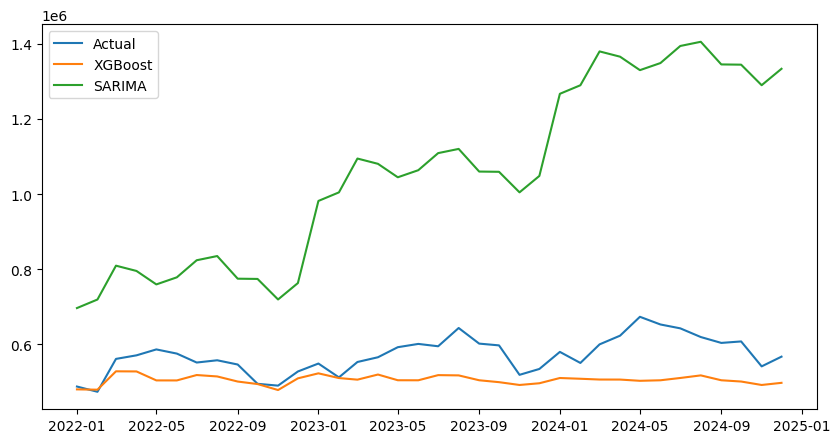

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test["Date"],y_test,label="Actual")
plt.plot(test["Date"],forecast_xgb,label="XGBoost")
plt.plot(test["Date"],forecast_sarima,label="SARIMA")

plt.legend()
plt.show()

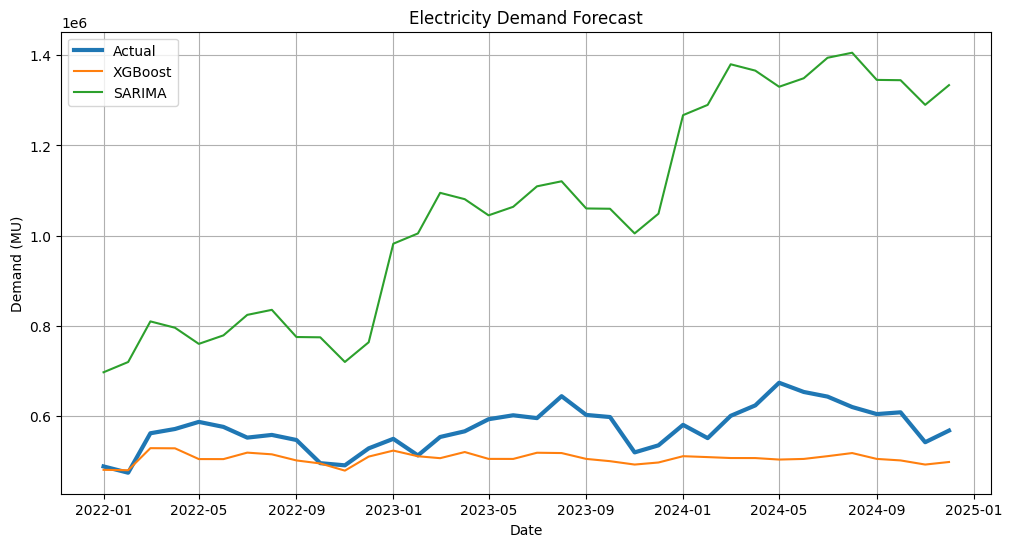

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test["Date"], y_test, label="Actual", linewidth=3)
plt.plot(test["Date"], forecast_xgb, label="XGBoost")
plt.plot(test["Date"], forecast_sarima, label="SARIMA")

plt.title("Electricity Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MU)")
plt.legend()
plt.grid(True)

plt.show()